In [1]:
import pandas as pd

csv_path = "/kaggle/input/datasets/robinchetry/data-csv/balanced_subset.csv"

df = pd.read_csv(csv_path)

print(df.shape)
print(df.columns.tolist())

df.head()

(24344, 7)
['image_id', 'panel_suffix', 'visualization_category', 'visualization_subtype', 'image_path', 'caption', 'summary']


,image_id,panel_suffix,visualization_category,visualization_subtype,image_path,caption,summary
0,ceramics_prod_img37464,B,Mechanical Test,Stress-Strain Curve,/mnt/home2/home/subham_g1/subham_CMEG/material...,Shear stress-strain curves for 3D-printed Ti6A...,Shear stress-strain curves are presented for 3...
1,ceramics_prod_img67212,A,Spectroscopy,EELS Spectrum,/mnt/home2/home/subham_g1/subham_CMEG/material...,Carbon and nitrogen K-edge EELS spectra of ABS...,The carbon and nitrogen K-edge EELS spectra fo...
2,ceramics_prod_img42745,B,Generic Plot,Histogram,/mnt/home2/home/subham_g1/subham_CMEG/material...,Frequency distribution histogram of GND values...,This histogram quantifies the GND value distri...
3,ceramics_prod_img33667,C,Electrochemistry,Nyquist Plot,/mnt/home2/home/subham_g1/subham_CMEG/material...,Nyquist plots derived from electrochemical imp...,Electrochemical impedance spectroscopy (EIS) t...
4,ni_alloy_img4271,B,Phase/Equilibrium Diagram,CALPHAD Diagram,/mnt/home2/home/subham_g1/subham_CMEG/material...,Critical temperature landscape for the α-phase...,Representing the α-phase critical temperatures...


In [2]:
for col in df.columns:
    print("\n", col)
    print(df[col].head())


 image_id
0    ceramics_prod_img37464
1    ceramics_prod_img67212
2    ceramics_prod_img42745
3    ceramics_prod_img33667
4          ni_alloy_img4271
Name: image_id, dtype: object

 panel_suffix
0    B
1    A
2    B
3    C
4    B
Name: panel_suffix, dtype: object

 visualization_category
0              Mechanical Test
1                 Spectroscopy
2                 Generic Plot
3             Electrochemistry
4    Phase/Equilibrium Diagram
Name: visualization_category, dtype: object

 visualization_subtype
0    Stress-Strain Curve
1          EELS Spectrum
2              Histogram
3           Nyquist Plot
4        CALPHAD Diagram
Name: visualization_subtype, dtype: object

 image_path
0    /mnt/home2/home/subham_g1/subham_CMEG/material...
1    /mnt/home2/home/subham_g1/subham_CMEG/material...
2    /mnt/home2/home/subham_g1/subham_CMEG/material...
3    /mnt/home2/home/subham_g1/subham_CMEG/material...
4    /mnt/home2/home/subham_g1/subham_CMEG/material...
Name: image_path, dtype: object

In [3]:
from pathlib import Path

image_dir = Path(
    "/kaggle/input/datasets/robinchetry/images-labelled/balanced_images"
)

all_images = list(
    image_dir.glob("*.jpg")
)

print("Images found:", len(all_images))
print(all_images[:5])

Images found: 24344
[PosixPath('/kaggle/input/datasets/robinchetry/images-labelled/balanced_images/ni_alloy_img855_C.jpg'), PosixPath('/kaggle/input/datasets/robinchetry/images-labelled/balanced_images/img15008_A.jpg'), PosixPath('/kaggle/input/datasets/robinchetry/images-labelled/balanced_images/ceramics_prod_img17103_B.jpg'), PosixPath('/kaggle/input/datasets/robinchetry/images-labelled/balanced_images/composite_img10662_C.jpg'), PosixPath('/kaggle/input/datasets/robinchetry/images-labelled/balanced_images/img509_B.jpg')]


In [4]:
print(df.iloc[0])

image_id                                             ceramics_prod_img37464
panel_suffix                                                              B
visualization_category                                      Mechanical Test
visualization_subtype                                   Stress-Strain Curve
image_path                /mnt/home2/home/subham_g1/subham_CMEG/material...
caption                   Shear stress-strain curves for 3D-printed Ti6A...
summary                   Shear stress-strain curves are presented for 3...
Name: 0, dtype: object


In [5]:
print(df.shape)
print(df.columns.tolist())
df.head()

(24344, 7)
['image_id', 'panel_suffix', 'visualization_category', 'visualization_subtype', 'image_path', 'caption', 'summary']


,image_id,panel_suffix,visualization_category,visualization_subtype,image_path,caption,summary
0,ceramics_prod_img37464,B,Mechanical Test,Stress-Strain Curve,/mnt/home2/home/subham_g1/subham_CMEG/material...,Shear stress-strain curves for 3D-printed Ti6A...,Shear stress-strain curves are presented for 3...
1,ceramics_prod_img67212,A,Spectroscopy,EELS Spectrum,/mnt/home2/home/subham_g1/subham_CMEG/material...,Carbon and nitrogen K-edge EELS spectra of ABS...,The carbon and nitrogen K-edge EELS spectra fo...
2,ceramics_prod_img42745,B,Generic Plot,Histogram,/mnt/home2/home/subham_g1/subham_CMEG/material...,Frequency distribution histogram of GND values...,This histogram quantifies the GND value distri...
3,ceramics_prod_img33667,C,Electrochemistry,Nyquist Plot,/mnt/home2/home/subham_g1/subham_CMEG/material...,Nyquist plots derived from electrochemical imp...,Electrochemical impedance spectroscopy (EIS) t...
4,ni_alloy_img4271,B,Phase/Equilibrium Diagram,CALPHAD Diagram,/mnt/home2/home/subham_g1/subham_CMEG/material...,Critical temperature landscape for the α-phase...,Representing the α-phase critical temperatures...


In [6]:
from pathlib import Path

image_dir = Path(
    "/kaggle/input/datasets/robinchetry/images-labelled/balanced_images"
)

df["filename"] = (
    df["image_id"]
    + "_"
    + df["panel_suffix"]
    + ".jpg"
)

df["full_path"] = df["filename"].apply(
    lambda x: image_dir / x
)

print(df["full_path"].iloc[0])

/kaggle/input/datasets/robinchetry/images-labelled/balanced_images/ceramics_prod_img37464_B.jpg


In [7]:
df["full_path"].apply(lambda x: x.exists()).mean()

np.float64(1.0)

In [ ]:
!pip install -q timm

In [ ]:
import torch
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "vit_base_patch14_dinov2.lvd142m",
    pretrained=True,
    num_classes=0,
    dynamic_img_size=True
)
device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)

print(next(model.parameters()).device)

In [ ]:
from tqdm.auto import tqdm

bad_images = 0

for path in tqdm(df["full_path"], desc="Checking images"):

    try:
        Image.open(path).convert("RGB")

    except:
        bad_images += 1

print("Bad images:", bad_images)

In [ ]:
from PIL import Image

path = df["full_path"].iloc[0]

print(path)
print(path.exists())

img = Image.open(str(path))

print(img.size)

In [ ]:
from PIL import Image

try:
    Image.open(df["full_path"].iloc[0]).convert("RGB")
    print("SUCCESS")

except Exception as e:
    print(type(e))
    print(e)

# embeddings

In [ ]:
from PIL import Image
from tqdm.auto import tqdm

bad_images = 0

sample_paths = df["full_path"].sample(
    100,
    random_state=42
)

for path in tqdm(
    sample_paths,
    desc="Testing images"
):

    try:
        img = Image.open(path).convert("RGB")

    except Exception as e:

        bad_images += 1
        print(path)
        print(e)

print("Bad images:", bad_images)

In [ ]:
print(model.default_cfg["input_size"])

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

In [ ]:
from PIL import Image

img = Image.open(
    str(df["full_path"].iloc[0])
).convert("RGB")

img = transform(img)

print(img.shape)

In [ ]:
with torch.no_grad():

    x = img.unsqueeze(0).to(device)

    y = model(x)

print(y.shape)

In [ ]:
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from PIL import Image
import numpy as np

In [ ]:
class MaterialDataset(Dataset):

    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = Image.open(
            str(self.paths[idx])
        ).convert("RGB")

        img = transform(img)

        return img

In [ ]:
dataset = MaterialDataset(
    df["full_path"].tolist()
)

loader = DataLoader(
    dataset,
    batch_size=32,      # safer for Kaggle GPU
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Batches:", len(loader))

In [ ]:
embeddings = []

model.eval()

with torch.no_grad():

    for batch in tqdm(
        loader,
        desc="Extracting DINO embeddings"
    ):

        batch = batch.to(device)

        feats = model(batch)

        embeddings.append(
            feats.cpu().numpy()
        )

embeddings = np.vstack(
    embeddings
)

print(embeddings.shape)

In [ ]:
np.save(
    "dino_embeddings_24k.npy",
    embeddings
)

print("Saved!")

In [ ]:
print(len(df))
print(len(embeddings))

In [ ]:
print(df["visualization_category"].nunique())
print(df["visualization_subtype"].nunique())

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(
    df["visualization_category"]
)

print(len(le.classes_))

# test with the knn model to see how much better are the dino embeddings 

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    embeddings,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print(X_train.shape)
print(X_test.shape)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="cosine"
)

knn.fit(
    X_train,
    y_train
)

preds = knn.predict(
    X_test
)

In [ ]:
 from sklearn.metrics import accuracy_score

acc = accuracy_score(
    y_test,
    preds
)

print(
    f"Accuracy = {acc:.4f}"
)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds,
        target_names=le.classes_
    )
)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    preds
)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

classes = le.classes_

mistakes = []

for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j and cm[i, j] > 0:
            mistakes.append(
                (
                    classes[i],
                    classes[j],
                    cm[i, j]
                )
            )

mistakes = sorted(
    mistakes,
    key=lambda x: x[2],
    reverse=True
)

pd.DataFrame(
    mistakes,
    columns=[
        "True",
        "Predicted",
        "Count"
    ]
).head(30)

# testing the embeddings with the xgboost model

In [ ]:
!pip install xgboost -q

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(
    df["visualization_category"]
)

X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(19475, 768)
(4869, 768)


In [49]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="multi:softprob",
    num_class=len(le.classes_),

    tree_method="hist",
    device="cuda",

    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_class=18, ...)

In [50]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)

acc = accuracy_score(
    y_test,
    preds
)

print(
    f"Accuracy = {acc:.4f}"
)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [06:17:25] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Accuracy = 0.6771


In [51]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds,
        target_names=le.classes_
    )
)


                           precision    recall  f1-score   support

        Compositional Map       0.65      0.44      0.53       163
        Crystal Structure       0.75      0.74      0.75       120
              Diffraction       0.78      0.73      0.75       343
         Electrochemistry       0.65      0.72      0.68       383
             Generic Plot       0.57      0.61      0.59       493
         Machine Learning       0.75      0.64      0.69       297
      Magnetic/Electronic       0.79      0.56      0.66       220
          Mechanical Test       0.48      0.60      0.54       499
               Microscopy       0.73      0.91      0.81       552
         Optical/Photonic       0.97      0.57      0.72       145
Phase/Equilibrium Diagram       0.86      0.81      0.83       185
               Photograph       0.66      0.79      0.72       149
        Schematic/Diagram       0.67      0.66      0.67       199
               Simulation       0.64      0.49      0.55     

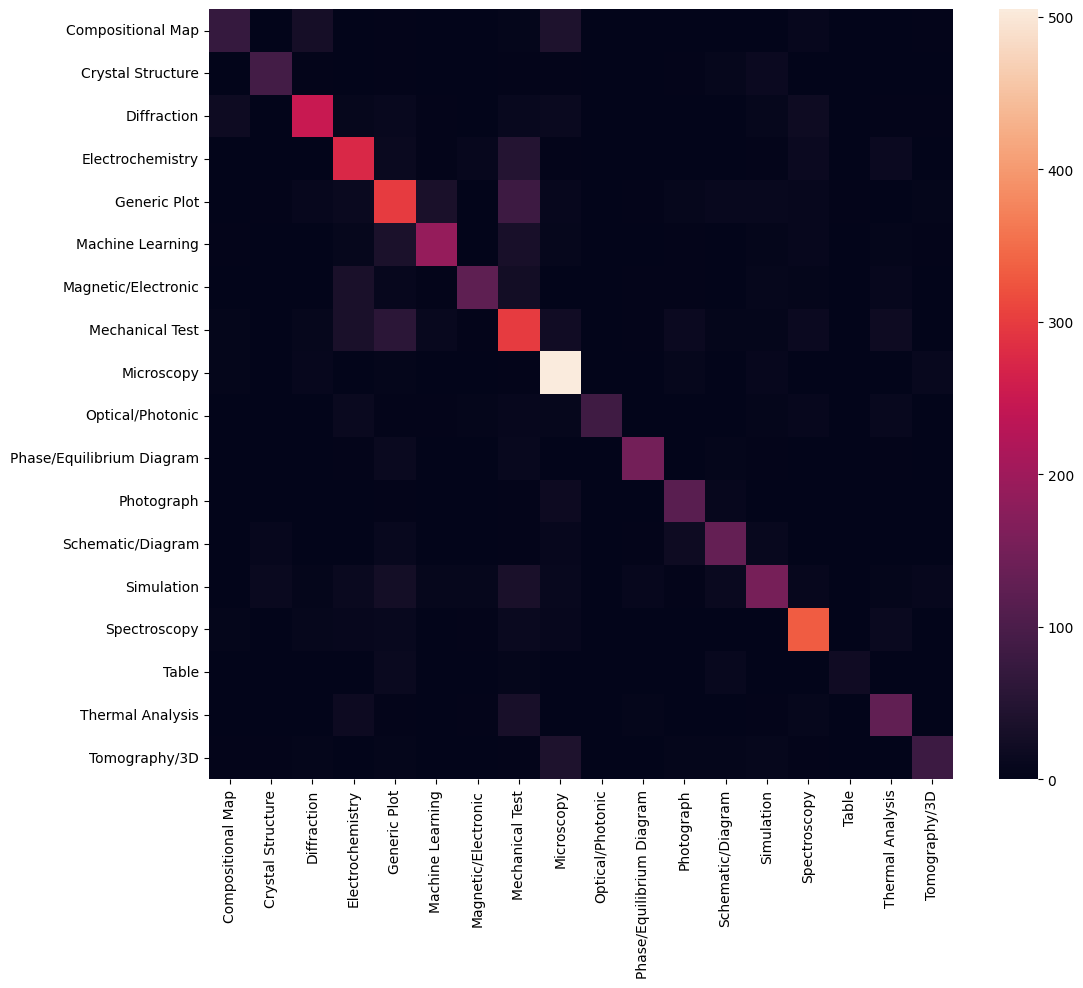

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.show()

We are no longer asking:

"Can embeddings classify categories?"

We already answered that (67.7% XGBoost).

Now we're asking:

"Can HDBSCAN discover those categories without labels?"
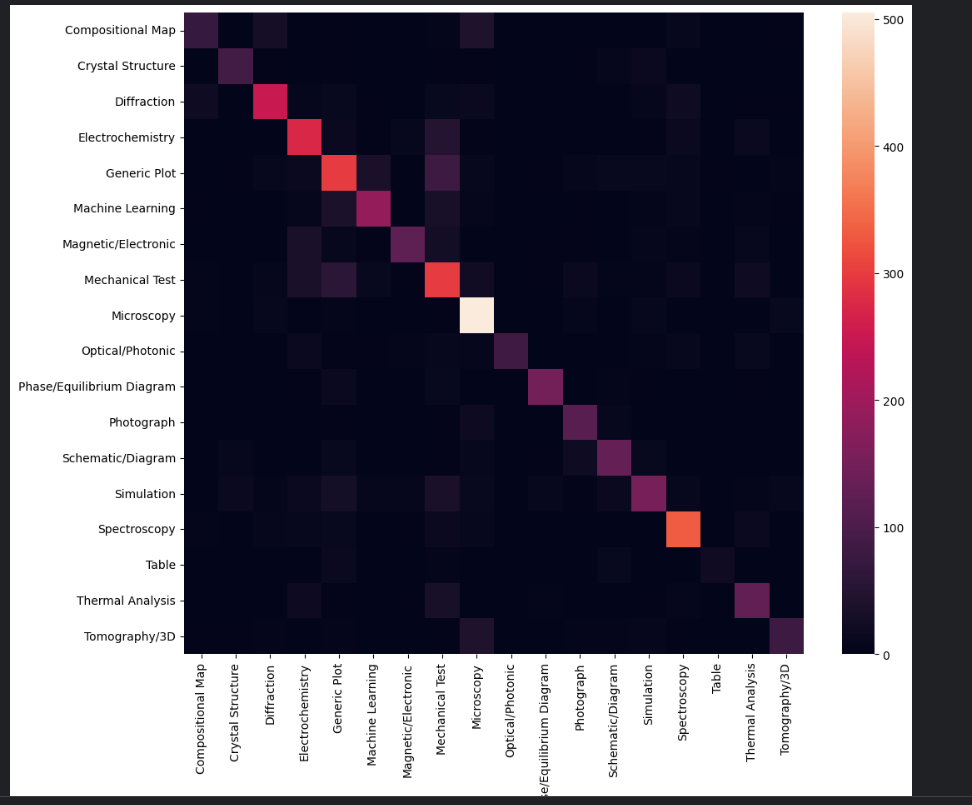

In [53]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_true = le.fit_transform(
    df["visualization_category"]
)

print("Classes:", len(le.classes_))
print(le.classes_)

Classes: 18
['Compositional Map' 'Crystal Structure' 'Diffraction' 'Electrochemistry'
 'Generic Plot' 'Machine Learning' 'Magnetic/Electronic' 'Mechanical Test'
 'Microscopy' 'Optical/Photonic' 'Phase/Equilibrium Diagram' 'Photograph'
 'Schematic/Diagram' 'Simulation' 'Spectroscopy' 'Table'
 'Thermal Analysis' 'Tomography/3D']


In [55]:
print(embeddings.shape)

(24344, 768)


In [56]:
from sklearn.decomposition import PCA
import hdbscan
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

pca = PCA(
    n_components=100,
    random_state=42
)

X_pca = pca.fit_transform(
    embeddings
)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=20,
    
    metric="euclidean"
)

cluster_labels = clusterer.fit_predict(
    X_pca
)

print("Clusters:",
      len(set(cluster_labels))
      - (1 if -1 in cluster_labels else 0))

print("Noise:",
      (cluster_labels == -1).sum())

Clusters: 5
Noise: 8726


In [57]:
ari = adjusted_rand_score(
    y_true,
    cluster_labels
)

nmi = normalized_mutual_info_score(
    y_true,
    cluster_labels
)

print("ARI =", ari)
print("NMI =", nmi)

ARI = 0.062178611089197595
NMI = 0.1871480121398266


In [58]:
import optuna
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
import hdbscan

In [60]:
def objective(trial):

    pca_dim = trial.suggest_int(
        "pca_dim",
        50,
        300
    )

    min_cluster_size = trial.suggest_int(
        "min_cluster_size",
        20,
        300
    )

    min_samples = trial.suggest_int(
        "min_samples",
        5,
        100
    )

    metric = trial.suggest_categorical(
        "metric",
        [
            "euclidean",
            "manhattan"
        ]
    )

    X_pca = PCA(
        n_components=pca_dim,
        random_state=42
    ).fit_transform(
        embeddings
    )

    labels = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=metric
    ).fit_predict(
        X_pca
    )

    n_clusters = (
        len(set(labels))
        - (1 if -1 in labels else 0)
    )

    if n_clusters < 2:
        return -1

    ari = adjusted_rand_score(
        y_true,
        labels
    )

    return ari

In [ ]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=20
)

[I 2026-06-11 06:30:54,569] A new study created in memory with name: no-name-defc7a25-66ff-43b0-927f-992a91769388
[I 2026-06-11 06:34:19,948] Trial 0 finished with value: 0.061817821992196424 and parameters: {'pca_dim': 191, 'min_cluster_size': 152, 'min_samples': 90, 'metric': 'euclidean'}. Best is trial 0 with value: 0.061817821992196424.
[I 2026-06-11 06:36:17,163] Trial 1 finished with value: 0.061738627865246164 and parameters: {'pca_dim': 106, 'min_cluster_size': 55, 'min_samples': 80, 'metric': 'manhattan'}. Best is trial 0 with value: 0.061817821992196424.


In [62]:
print("Clusters:",
      len(set(cluster_labels))
      - (1 if -1 in cluster_labels else 0))

print("Noise:",
      (cluster_labels == -1).sum())

import pandas as pd

pd.Series(cluster_labels).value_counts().head(20)

Clusters: 5
Noise: 8726


 2    14716
-1     8726
 3      376
 1      214
 0      182
 4      130
Name: count, dtype: int64

In [65]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

pca = PCA(
    n_components=100,
    random_state=42
)

X_pca = pca.fit_transform(
    embeddings
)

kmeans = KMeans(
    n_clusters=18,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(
    X_pca
)

ari = adjusted_rand_score(
    y_true,
    labels
)

nmi = normalized_mutual_info_score(
    y_true,
    labels
)

print("ARI =", ari)
print("NMI =", nmi)

ARI = 0.15147429622513556
NMI = 0.29027680787460364


In [63]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=18,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(
    embeddings
)

In [64]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

ari = adjusted_rand_score(
    y_true,
    kmeans_labels
)

nmi = normalized_mutual_info_score(
    y_true,
    kmeans_labels
)

print("ARI =", ari)
print("NMI =", nmi)

ARI = 0.15401127991074104
NMI = 0.29218559628693375


# **experimentation with slig**

In [8]:
!pip install -q transformers accelerate timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 75.7 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [9]:
import os
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm

import torch

from transformers import (
    AutoProcessor,
    AutoModel
)

In [10]:
print(df.shape)

df.head()

(24344, 9)


,image_id,panel_suffix,visualization_category,visualization_subtype,image_path,caption,summary,filename,full_path
0,ceramics_prod_img37464,B,Mechanical Test,Stress-Strain Curve,/mnt/home2/home/subham_g1/subham_CMEG/material...,Shear stress-strain curves for 3D-printed Ti6A...,Shear stress-strain curves are presented for 3...,ceramics_prod_img37464_B.jpg,/kaggle/input/datasets/robinchetry/images-labe...
1,ceramics_prod_img67212,A,Spectroscopy,EELS Spectrum,/mnt/home2/home/subham_g1/subham_CMEG/material...,Carbon and nitrogen K-edge EELS spectra of ABS...,The carbon and nitrogen K-edge EELS spectra fo...,ceramics_prod_img67212_A.jpg,/kaggle/input/datasets/robinchetry/images-labe...
2,ceramics_prod_img42745,B,Generic Plot,Histogram,/mnt/home2/home/subham_g1/subham_CMEG/material...,Frequency distribution histogram of GND values...,This histogram quantifies the GND value distri...,ceramics_prod_img42745_B.jpg,/kaggle/input/datasets/robinchetry/images-labe...
3,ceramics_prod_img33667,C,Electrochemistry,Nyquist Plot,/mnt/home2/home/subham_g1/subham_CMEG/material...,Nyquist plots derived from electrochemical imp...,Electrochemical impedance spectroscopy (EIS) t...,ceramics_prod_img33667_C.jpg,/kaggle/input/datasets/robinchetry/images-labe...
4,ni_alloy_img4271,B,Phase/Equilibrium Diagram,CALPHAD Diagram,/mnt/home2/home/subham_g1/subham_CMEG/material...,Critical temperature landscape for the α-phase...,Representing the α-phase critical temperatures...,ni_alloy_img4271_B.jpg,/kaggle/input/datasets/robinchetry/images-labe...


In [11]:
from transformers import AutoProcessor
from transformers import SiglipVisionModel

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(
    "google/siglip-base-patch16-224"
)

model = SiglipVisionModel.from_pretrained(
    "google/siglip-base-patch16-224"
)

model = model.to(device)
model.eval()

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.w

SiglipVisionModel(
  (vision_model): SiglipVisionTransformer(
    (embeddings): SiglipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
      (position_embedding): Embedding(196, 768)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-11): 12 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): GELUTanh()
            (fc1): Linear(in_features=768, out_features=3072, bias=Tr

In [12]:
img = Image.open(
    df["full_path"].iloc[0]
).convert("RGB")

inputs = processor(
    images=img,
    return_tensors="pt"
)

inputs = {
    k:v.to(device)
    for k,v in inputs.items()
}

In [13]:
with torch.no_grad():

    outputs = model(
        pixel_values=inputs["pixel_values"]
    )

print(outputs.pooler_output.shape)

torch.Size([1, 768])


In [14]:
def extract_embedding(path):

    image = Image.open(path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():

        features = model(
            pixel_values=pixel_values
        ).pooler_output

    return features.cpu().numpy()[0]

In [15]:
print(outputs.pooler_output.shape)

torch.Size([1, 768])


In [16]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class ImageDataset(Dataset):

    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = Image.open(
            self.paths[idx]
        ).convert("RGB")

        return img

In [17]:
def collate_fn(batch):

    inputs = processor(
        images=batch,
        return_tensors="pt"
    )
    

    return inputs["pixel_values"]

In [18]:
dataset = ImageDataset(
    df["full_path"].tolist()
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn
)

In [19]:
from tqdm.auto import tqdm
import numpy as np

embeddings = []

with torch.no_grad():

    for pixel_values in tqdm(loader):

        pixel_values = pixel_values.to(device)

        feats = model(
            pixel_values=pixel_values
        ).pooler_output

        embeddings.append(
            feats.cpu().numpy()
        )

embeddings = np.concatenate(
    embeddings,
    axis=0
)

print(embeddings.shape)

  0%|          | 0/381 [00:00<?, ?it/s]

(24344, 768)


In [21]:
np.save(
    "siglip_embeddings.npy",
    embeddings
)

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(
    df["visualization_category"]
)

print(len(le.classes_))
print(le.classes_)

18
['Compositional Map' 'Crystal Structure' 'Diffraction' 'Electrochemistry'
 'Generic Plot' 'Machine Learning' 'Magnetic/Electronic' 'Mechanical Test'
 'Microscopy' 'Optical/Photonic' 'Phase/Equilibrium Diagram' 'Photograph'
 'Schematic/Diagram' 'Simulation' 'Spectroscopy' 'Table'
 'Thermal Analysis' 'Tomography/3D']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(19475, 768)
(4869, 768)


In [24]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="multi:softmax",
    num_class=len(le.classes_),

    tree_method="hist",
    device="cuda",

    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_class=18, ...)

In [25]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)

acc = accuracy_score(
    y_test,
    preds
)

print(
    f"Accuracy = {acc:.4f}"
)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [09:25:04] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Accuracy = 0.7427


In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds,
        target_names=le.classes_
    )
)

                           precision    recall  f1-score   support

        Compositional Map       0.69      0.50      0.58       163
        Crystal Structure       0.76      0.81      0.79       120
              Diffraction       0.78      0.76      0.77       343
         Electrochemistry       0.81      0.89      0.85       383
             Generic Plot       0.59      0.68      0.63       493
         Machine Learning       0.80      0.80      0.80       297
      Magnetic/Electronic       0.81      0.68      0.74       220
          Mechanical Test       0.68      0.70      0.69       499
               Microscopy       0.76      0.91      0.83       552
         Optical/Photonic       0.89      0.68      0.77       145
Phase/Equilibrium Diagram       0.88      0.88      0.88       185
               Photograph       0.70      0.71      0.70       149
        Schematic/Diagram       0.65      0.73      0.69       199
               Simulation       0.63      0.45      0.53     

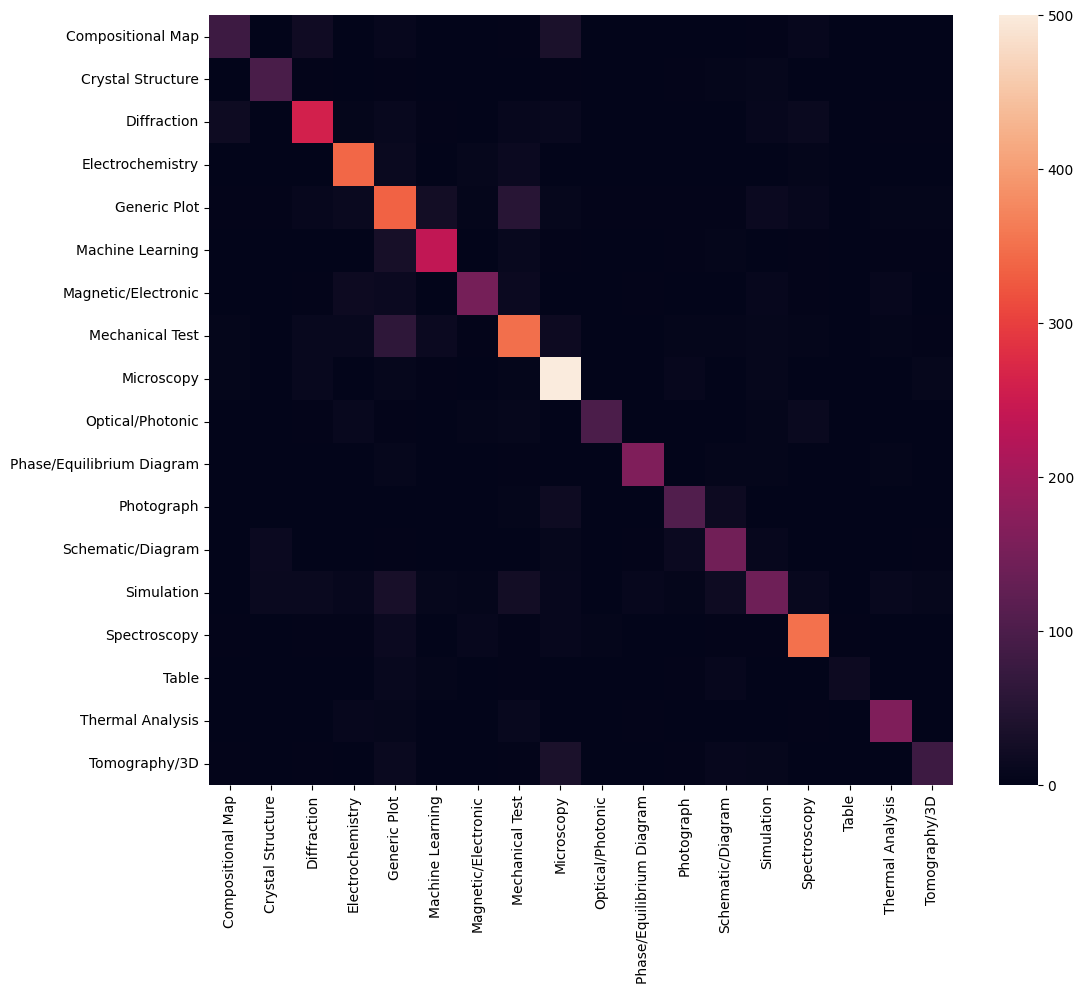

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.show()

In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=18,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(
    embeddings
)

In [31]:
    from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

ari = adjusted_rand_score(
    y,
    kmeans_labels
)

nmi = normalized_mutual_info_score(
    y,
    kmeans_labels
)

print("ARI =", ari)
print("NMI =", nmi)

ARI = 0.20605826984089343
NMI = 0.35970966614156114


In [32]:
import pandas as pd

cluster_df = pd.DataFrame({
    "cluster": kmeans_labels,
    "label": le.inverse_transform(y),
    "path": df["full_path"]
})

cluster_df.head()

,cluster,label,path
0,11,Mechanical Test,/kaggle/input/datasets/robinchetry/images-labe...
1,15,Spectroscopy,/kaggle/input/datasets/robinchetry/images-labe...
2,12,Generic Plot,/kaggle/input/datasets/robinchetry/images-labe...
3,13,Electrochemistry,/kaggle/input/datasets/robinchetry/images-labe...
4,4,Phase/Equilibrium Diagram,/kaggle/input/datasets/robinchetry/images-labe...


In [36]:
purity_rows = []

for cluster_id in sorted(cluster_df["cluster"].unique()):

    temp = cluster_df[
        cluster_df["cluster"] == cluster_id
    ]

    counts = temp["label"].value_counts()

    dominant_label = counts.index[0]

    dominant_count = counts.iloc[0]

    cluster_size = len(temp)

    purity = dominant_count / cluster_size

    purity_rows.append({
        "cluster": cluster_id,
        "size": cluster_size,
        "dominant_label": dominant_label,
        "purity": purity
    })

purity_df = pd.DataFrame(
    purity_rows
)

purity_df = purity_df.sort_values(
    "purity",
    ascending=False
)

purity_df

,cluster,size,dominant_label,purity
1,1,1916,Microscopy,0.790710
2,2,452,Photograph,0.690265
8,8,936,Microscopy,0.614316
17,17,988,Schematic/Diagram,0.526316
10,10,963,Spectroscopy,0.522326
7,7,737,Crystal Structure,0.507463
0,0,1333,Machine Learning,0.503376
12,12,1959,Spectroscopy,0.474732
4,4,496,Phase/Equilibrium Diagram,0.455645
3,3,1963,Thermal Analysis,0.400408


In [37]:
print(
    "Mean purity:",
    purity_df["purity"].mean()
)

print(
    "Median purity:",
    purity_df["purity"].median()
)

Mean purity: 0.4439890646195522
Median purity: 0.42802635038535486


In [38]:
for cluster_id in sorted(cluster_df["cluster"].unique()):

    print("\n" + "="*60)
    print(f"CLUSTER {cluster_id}")

    temp = cluster_df[
        cluster_df["cluster"] == cluster_id
    ]

    print(
        temp["label"]
        .value_counts()
        .head(5)
    )


CLUSTER 0
label
Machine Learning    671
Generic Plot        296
Mechanical Test     131
Simulation           83
Spectroscopy         30
Name: count, dtype: int64

CLUSTER 1
label
Microscopy           1515
Tomography/3D         105
Photograph            101
Compositional Map      71
Diffraction            30
Name: count, dtype: int64

CLUSTER 2
label
Photograph             312
Schematic/Diagram      109
Magnetic/Electronic      7
Tomography/3D            5
Simulation               5
Name: count, dtype: int64

CLUSTER 3
label
Thermal Analysis             786
Phase/Equilibrium Diagram    458
Magnetic/Electronic          188
Simulation                   136
Generic Plot                 121
Name: count, dtype: int64

CLUSTER 4
label
Phase/Equilibrium Diagram    226
Generic Plot                 207
Diffraction                   24
Simulation                    12
Machine Learning              10
Name: count, dtype: int64

CLUSTER 5
label
Schematic/Diagram    238
Photograph           207
Sim

In [39]:
import matplotlib.pyplot as plt
from PIL import Image
import random

In [40]:
def show_cluster(cluster_id, n=16):

    temp = cluster_df[
        cluster_df["cluster"] == cluster_id
    ]

    paths = temp["path"].sample(
        min(n, len(temp)),
        random_state=42
    )

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(12,12)
    )

    axes = axes.flatten()

    for ax, path in zip(axes, paths):

        img = Image.open(path)

        ax.imshow(img)

        ax.axis("off")

    plt.suptitle(
        f"Cluster {cluster_id}",
        fontsize=18
    )

    plt.tight_layout()

    plt.show()

In [41]:
purity_df.head(10)

,cluster,size,dominant_label,purity
1,1,1916,Microscopy,0.790710
2,2,452,Photograph,0.690265
8,8,936,Microscopy,0.614316
17,17,988,Schematic/Diagram,0.526316
10,10,963,Spectroscopy,0.522326
7,7,737,Crystal Structure,0.507463
0,0,1333,Machine Learning,0.503376
12,12,1959,Spectroscopy,0.474732
4,4,496,Phase/Equilibrium Diagram,0.455645
3,3,1963,Thermal Analysis,0.400408


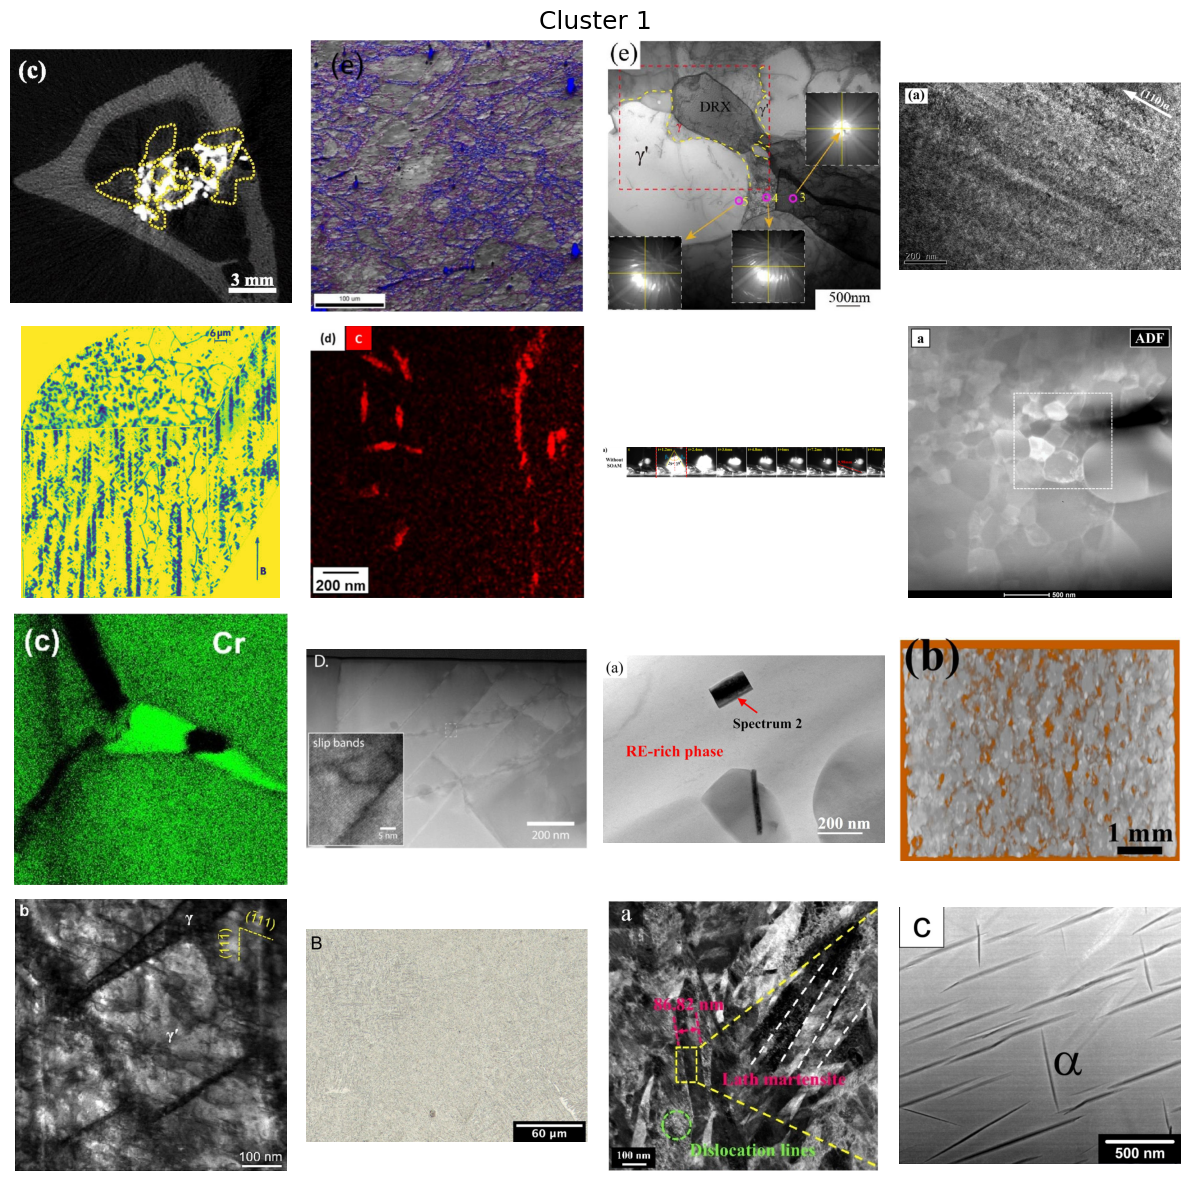

In [42]:
best_cluster = purity_df.iloc[0]["cluster"]

show_cluster(best_cluster)

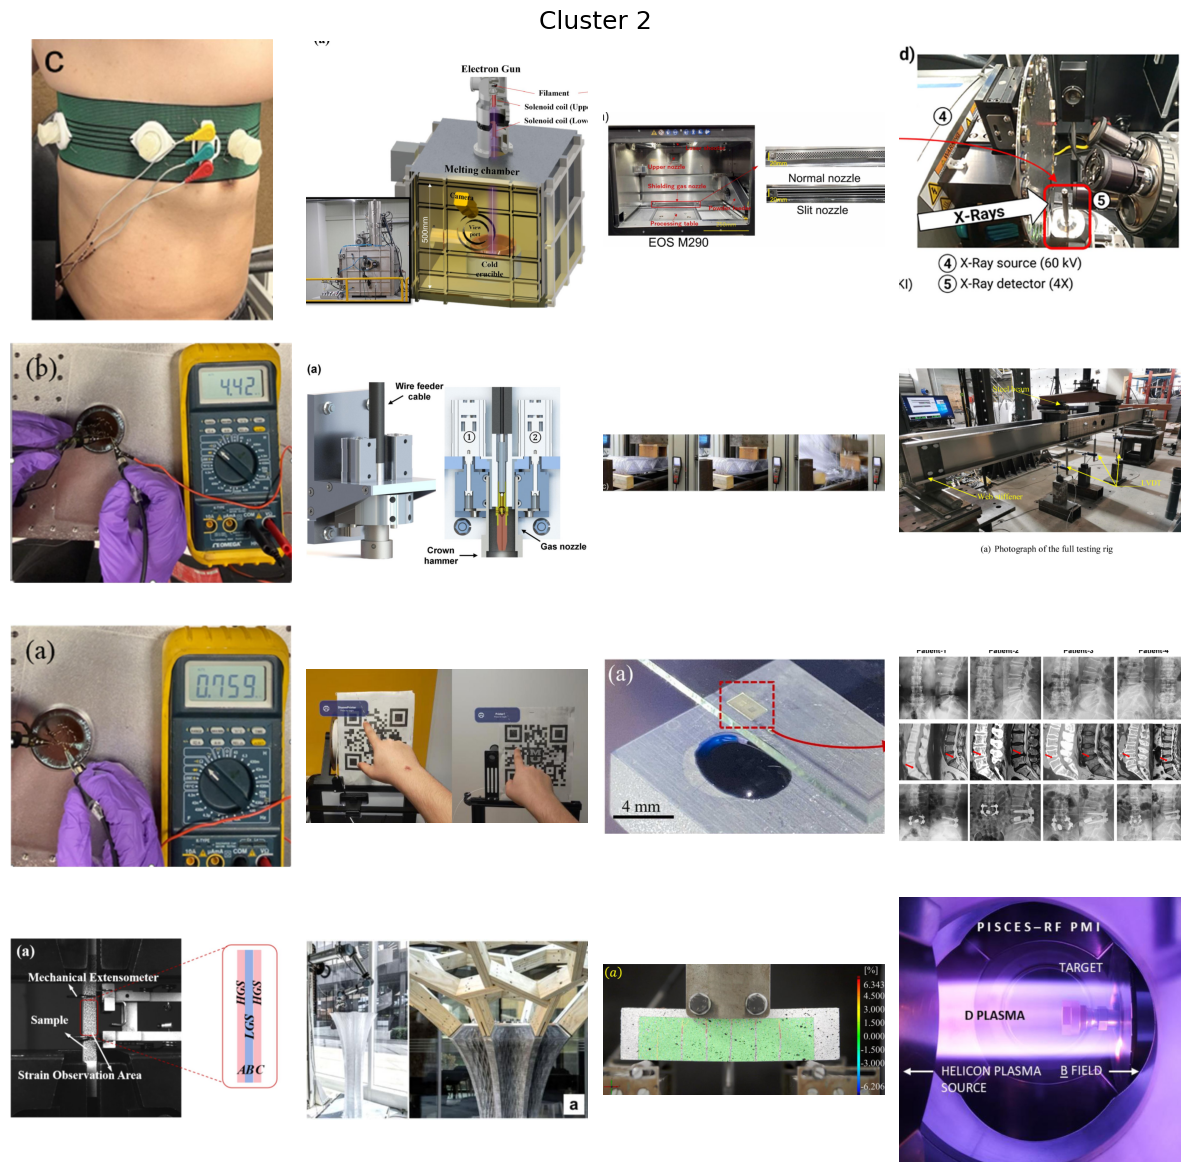

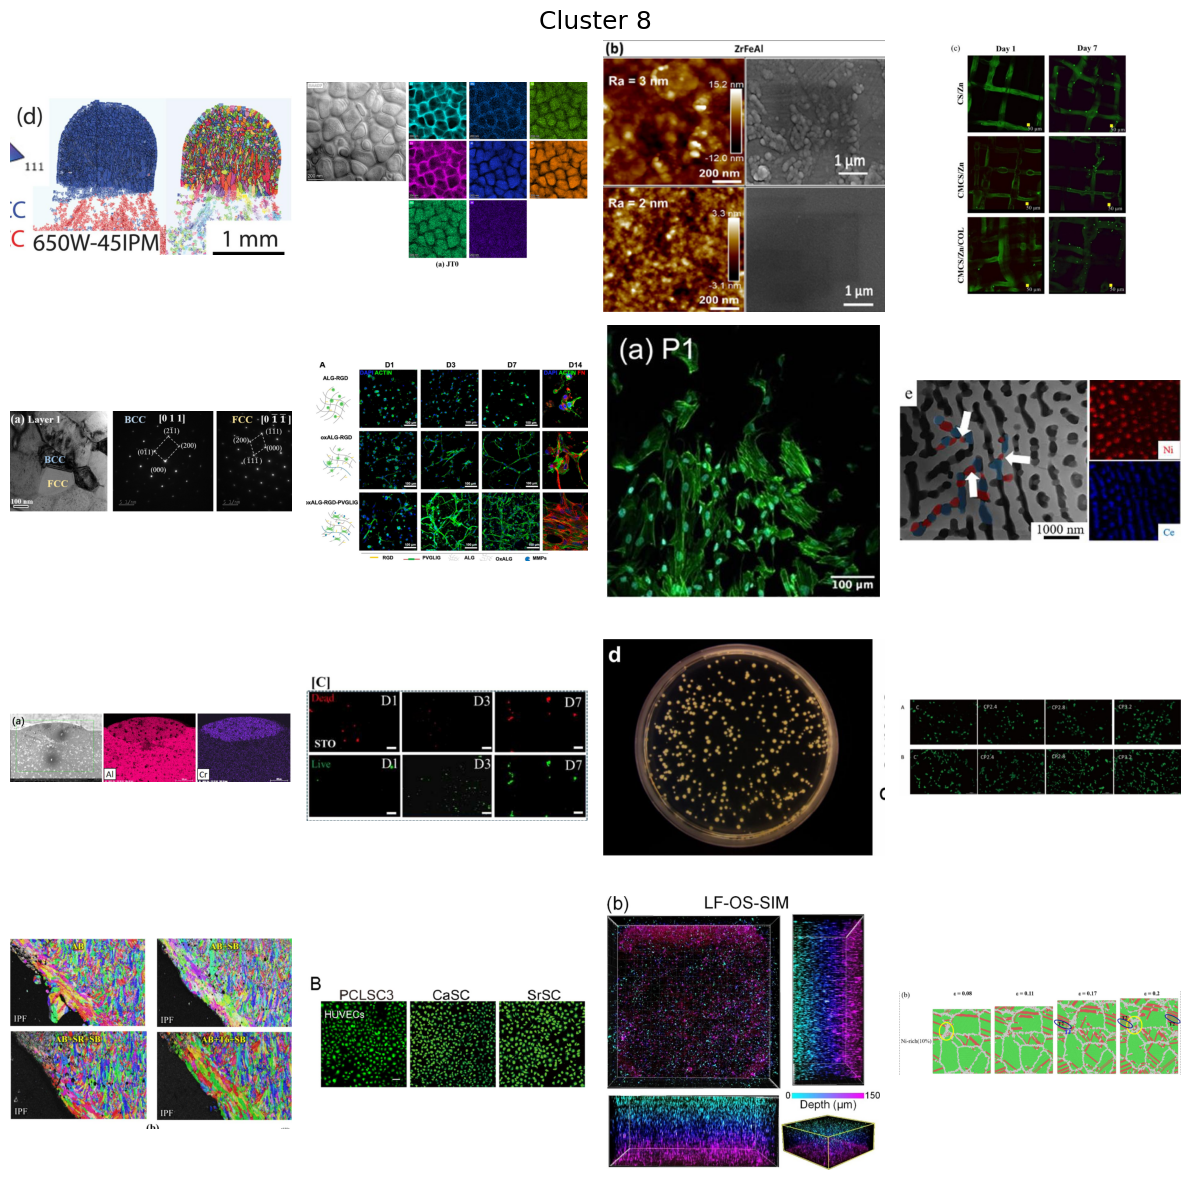

In [43]:
show_cluster(
    purity_df.iloc[1]["cluster"]
)

show_cluster(
    purity_df.iloc[2]["cluster"]
)

In [44]:
purity_df.tail(5)

,cluster,size,dominant_label,purity
11,11,2609,Mechanical Test,0.371790
16,16,1407,Generic Plot,0.325515
15,15,1255,Spectroscopy,0.220717
9,9,1532,Diffraction,0.214752
5,5,1137,Schematic/Diagram,0.209323


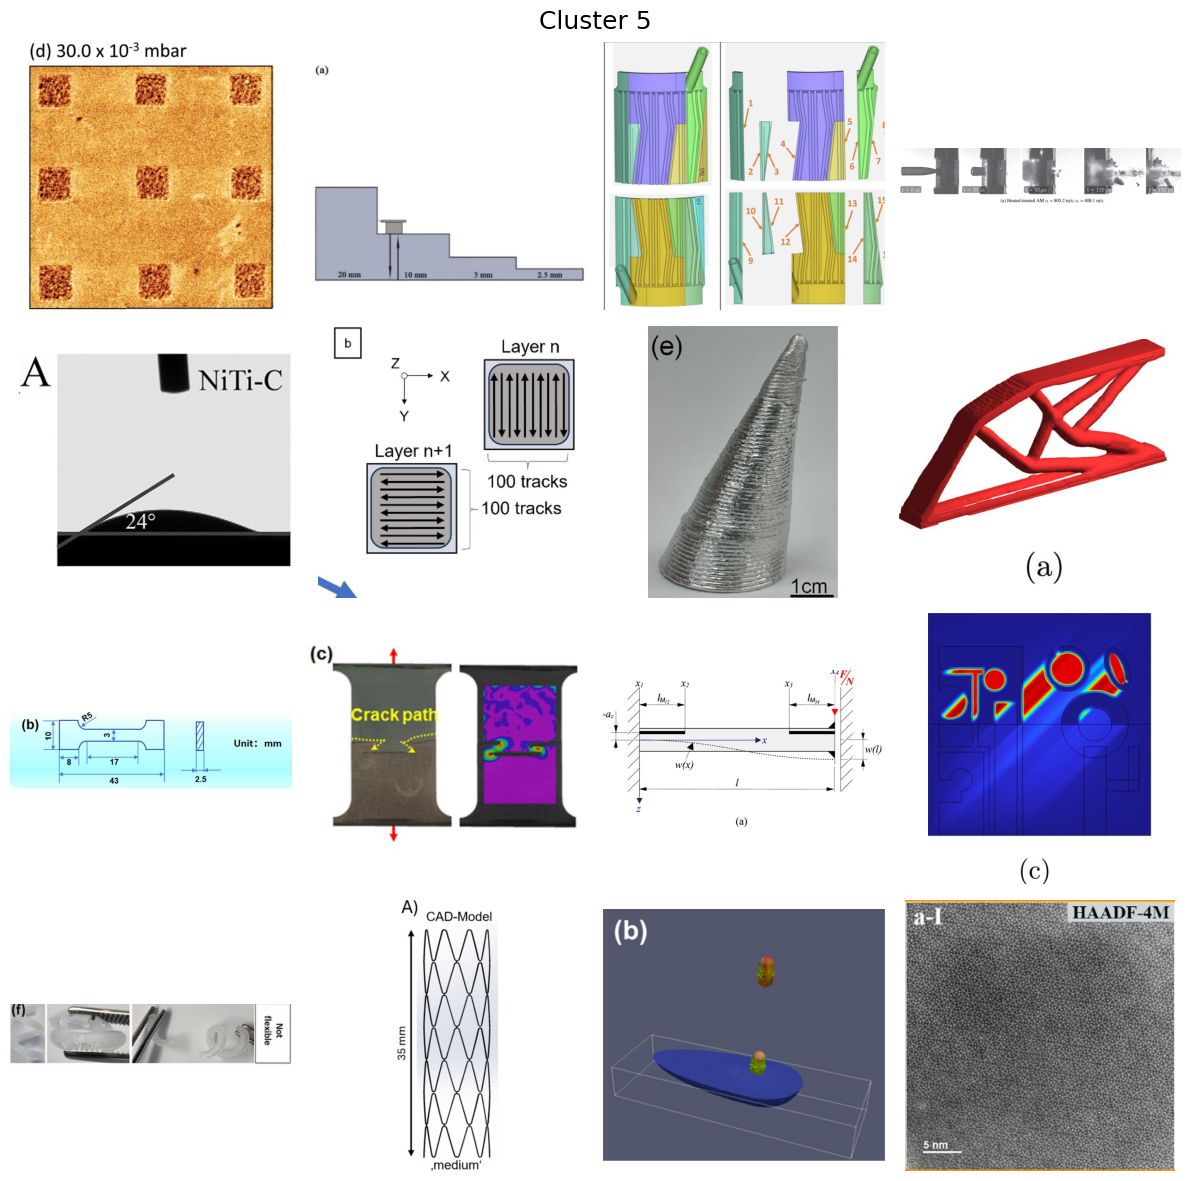

In [45]:
show_cluster(5)

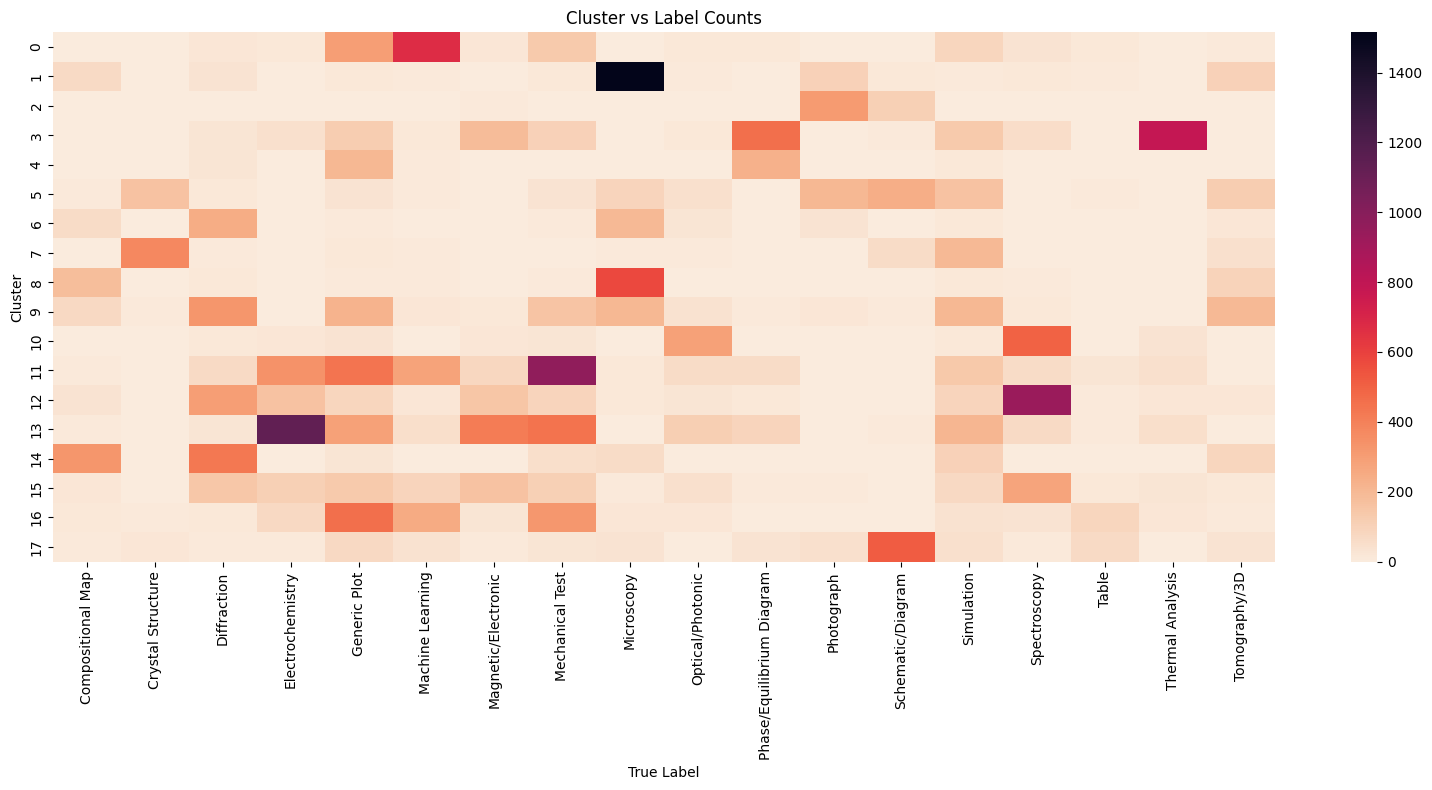

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = pd.crosstab(
    cluster_df["cluster"],
    cluster_df["label"]
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_df,
    cmap="rocket_r"
)

plt.title("Cluster vs Label Counts")

plt.xlabel("True Label")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

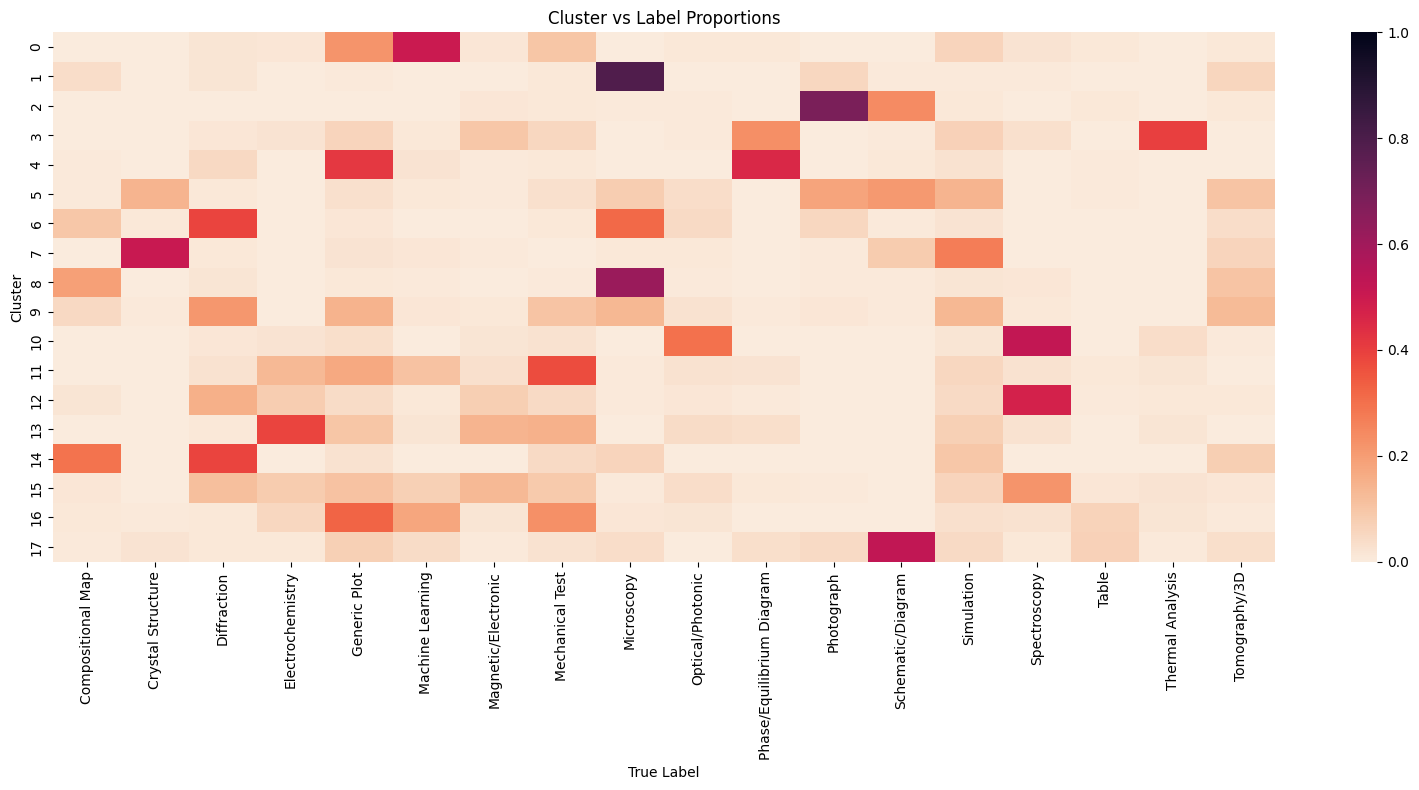

In [47]:
heatmap_norm = pd.crosstab(
    cluster_df["cluster"],
    cluster_df["label"],
    normalize="index"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_norm,
    cmap="rocket_r",
    vmin=0,
    vmax=1
)

plt.title("Cluster vs Label Proportions")

plt.xlabel("True Label")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

In [48]:
label_cluster_spread = pd.crosstab(
    cluster_df["label"],
    cluster_df["cluster"]
)

spread_df = pd.DataFrame({
    "label": label_cluster_spread.index,
    "clusters_used": (
        label_cluster_spread > 0
    ).sum(axis=1)
})

spread_df = spread_df.sort_values(
    "clusters_used",
    ascending=False
)

spread_df

,label,clusters_used
label,,
Simulation,Simulation,18
Generic Plot,Generic Plot,18
Optical/Photonic,Optical/Photonic,17
Tomography/3D,Tomography/3D,17
Machine Learning,Machine Learning,17
Diffraction,Diffraction,17
Schematic/Diagram,Schematic/Diagram,17
Mechanical Test,Mechanical Test,17
Magnetic/Electronic,Magnetic/Electronic,16


In [49]:
import pandas as pd

rows = []

for label in sorted(cluster_df["label"].unique()):

    temp = cluster_df[
        cluster_df["label"] == label
    ]

    total_images = len(temp)

    cluster_counts = (
        temp["cluster"]
        .value_counts()
    )

    biggest_cluster = cluster_counts.index[0]

    biggest_count = cluster_counts.iloc[0]

    fraction = biggest_count / total_images

    rows.append({
        "label": label,
        "total_images": total_images,
        "largest_cluster": biggest_cluster,
        "largest_cluster_count": biggest_count,
        "fraction": fraction
    })

label_coherence_df = pd.DataFrame(rows)

label_coherence_df = (
    label_coherence_df
    .sort_values(
        "fraction",
        ascending=False
    )
)

label_coherence_df

,label,total_images,largest_cluster,largest_cluster_count,fraction
16,Thermal Analysis,987,3,786,0.796353
1,Crystal Structure,599,7,374,0.624374
3,Electrochemistry,1916,13,1132,0.590814
8,Microscopy,2760,1,1515,0.548913
12,Schematic/Diagram,994,17,520,0.523139
10,Phase/Equilibrium Diagram,923,3,458,0.496208
14,Spectroscopy,2033,12,930,0.457452
5,Machine Learning,1485,0,671,0.451852
11,Photograph,747,2,312,0.417671
0,Compositional Map,815,14,327,0.401227


In [50]:
label_coherence_df["fraction"] = (
    label_coherence_df["fraction"] * 100
).round(2)

label_coherence_df

,label,total_images,largest_cluster,largest_cluster_count,fraction
16,Thermal Analysis,987,3,786,79.64
1,Crystal Structure,599,7,374,62.44
3,Electrochemistry,1916,13,1132,59.08
8,Microscopy,2760,1,1515,54.89
12,Schematic/Diagram,994,17,520,52.31
10,Phase/Equilibrium Diagram,923,3,458,49.62
14,Spectroscopy,2033,12,930,45.75
5,Machine Learning,1485,0,671,45.19
11,Photograph,747,2,312,41.77
0,Compositional Map,815,14,327,40.12


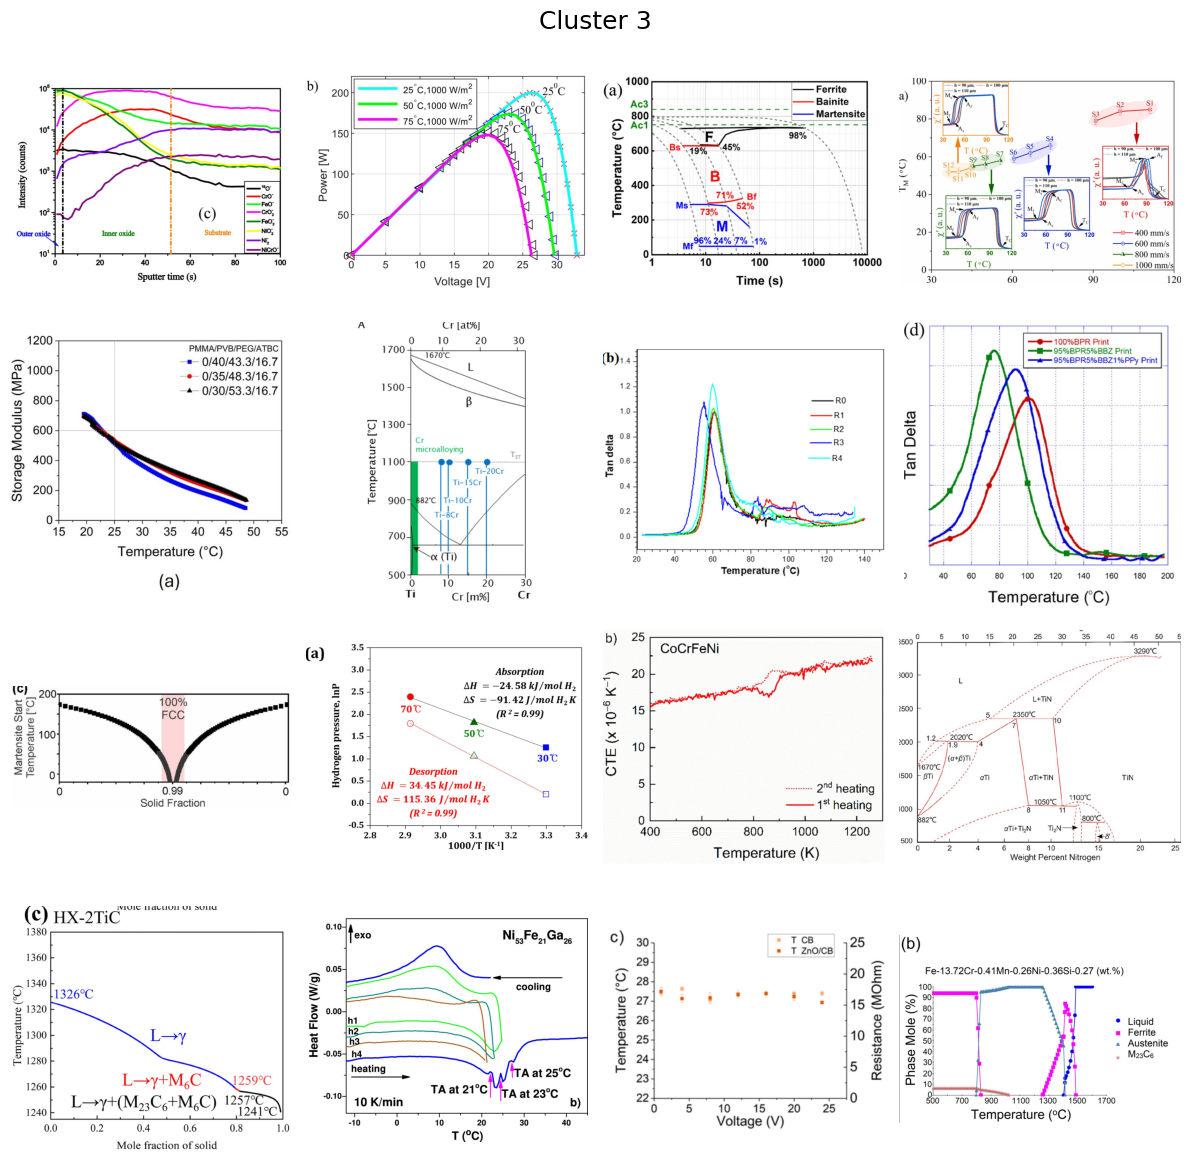

In [51]:
thermal_cluster = (
    cluster_df[
        cluster_df["label"] == "Thermal Analysis"
    ]["cluster"]
    .value_counts()
    .idxmax()
)

show_cluster(thermal_cluster)

In [52]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

from tqdm.auto import tqdm
import pandas as pd

results = []

k_values = [
    5,
    8,
    10,
    12,
    15,
    18,
    20,
    25,
    30,
    35,
    40
]

for k in tqdm(
    k_values,
    desc="Testing KMeans"
):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(
        embeddings
    )

    ari = adjusted_rand_score(
        y,
        labels
    )

    nmi = normalized_mutual_info_score(
        y,
        labels
    )

    results.append({
        "k": k,
        "ARI": ari,
        "NMI": nmi
    })

results_df = pd.DataFrame(
    results
)

results_df

Testing KMeans:   0%|          | 0/11 [00:00<?, ?it/s]

,k,ARI,NMI
0,5,0.141275,0.304058
1,8,0.219431,0.355000
2,10,0.215894,0.343345
3,12,0.214046,0.352164
4,15,0.208608,0.361131
5,18,0.206058,0.359710
6,20,0.186310,0.361386
7,25,0.175082,0.365797
8,30,0.167326,0.367554
9,35,0.161710,0.366429


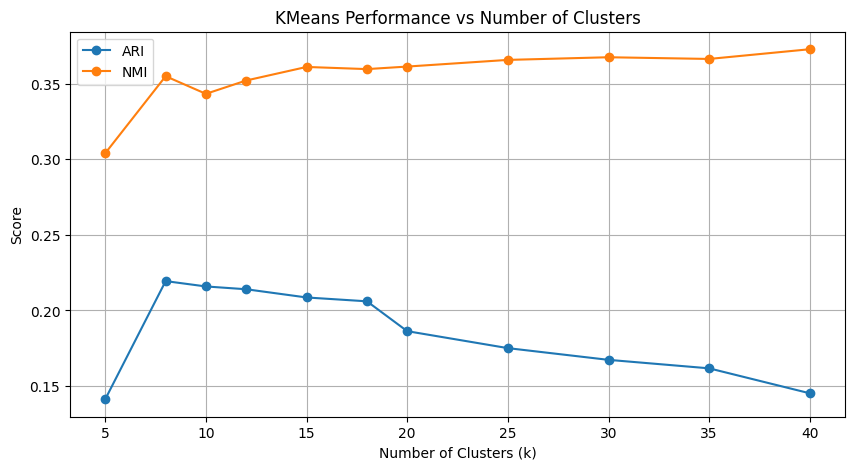

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    results_df["k"],
    results_df["ARI"],
    marker="o",
    label="ARI"
)

plt.plot(
    results_df["k"],
    results_df["NMI"],
    marker="o",
    label="NMI"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")

plt.title(
    "KMeans Performance vs Number of Clusters"
)

plt.legend()

plt.grid(True)

plt.show()